In [52]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import RegularGridInterpolator

In [53]:
Gyr2sec = 1e9 * 365 * 24 * 3600

MPBH_values = np.logspace(13, 20, 15)
rho_values = np.logspace(6, 9, 15)

base_dir = "../../blackhawk_v2.3/results/PBH_evolution"
cases = ["bondi", "unruh"]

In [54]:
def read_lifetime(path):
    with open(path, "r") as f:
        lines = f.readlines()
    last_t = None
    for line in lines[2:]:
        line = line.strip()
        if not line:
            continue
        last_t = float(line.split()[0])
    return last_t

In [55]:
n_fine = 200
log_M_base = np.log10(MPBH_values)
log_rho_base = np.log10(rho_values)

rho_fine = np.logspace(log_rho_base.min(), log_rho_base.max(), n_fine)
M_fine = np.logspace(log_M_base.min(), log_M_base.max(), n_fine)
rho_fine_grid, M_fine_grid = np.meshgrid(rho_fine, M_fine)
eval_points = np.column_stack([np.log10(rho_fine_grid).ravel(), np.log10(M_fine_grid).ravel()])

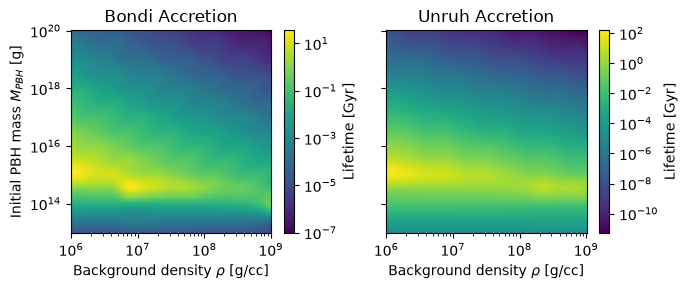

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

for ax, case in zip(axes, cases):
    results_dir = os.path.join(base_dir, case)
    lifetime = np.full((len(rho_values), len(MPBH_values)), np.nan)
    
    for i, rho in enumerate(rho_values):
        for j, M in enumerate(MPBH_values):
            path = os.path.join(results_dir, f"M{M:.2e}", f"rho{rho:.2e}", "dts.txt")
            lifetime[i, j] = read_lifetime(path) / Gyr2sec
            
    log_life = np.log10(lifetime)
    
    interp_func = RegularGridInterpolator(
        (log_rho_base, log_M_base),
        log_life,
        method="cubic",
        bounds_error=False,
        fill_value=None
    )
    
    log_life_fine = interp_func(eval_points).reshape(n_fine, n_fine)
    lifetime_fine = 10.**log_life_fine
    
    norm = LogNorm(vmin=lifetime_fine.min(), vmax=lifetime_fine.max()) if lifetime_fine.size else None
    
    mesh = ax.pcolormesh(rho_fine, M_fine, lifetime_fine, shading="auto", norm=norm, cmap="viridis", rasterized=True)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Background density $\rho$ [g/cc]")
    ax.set_title(f"{case.capitalize()} Accretion")
    
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Lifetime [Gyr]")

axes[0].set_ylabel("Initial PBH mass $M_{PBH}$ [g]")

plt.tight_layout()
plt.savefig("../../img/lifetime.pgf")